## Base Line Models

In [207]:
import pandas as pd
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [208]:
train = pd.read_csv("../data/clean_train.csv", sep=',')
test = pd.read_csv("../data/clean_test.csv", sep=',')

In [209]:
train.head(2)

,titre,type,difficulte,cout,ingredients,recette,clean_recette,clean_ingredients
0,"Feuilleté de saumon et de poireau, sauce aux c...",Plat principal,Facile,Moyen,- 1 gros pavé de saumon - 100 g de crevettes d...,Couper finement le blanc et un peu de vert des...,couper finement blanc vert poireau rondell épl...,1 gros pavé saumon 100 gramme crevette décorti...
1,Cake poulet/moutarde/amandes,Entrée,Très facile,Bon marché,- 3 œufs - 150 g de farine - 1 sachet de levur...,"Couper finement l'échalote, la faire revenir à...",couper finement échalote faire revenir poêle h...,3 œuf 150 gramme farine 1 sachet levure 10 cl ...


## Test Spliting

In [210]:
X = train["clean_recette"]
y = train["type"]
X_test = test["clean_recette"]
y_test = test["type"]

In [211]:
X_train, X_val, y_train, y_val = train_test_split(X, y,  random_state=42)

In [212]:
def modelisation(X_train, y_train, X_test, y_test, model=None):
    model = model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores = model.score(X_train,y_train), accuracy_score(y_test,y_pred)
    results = f"Train score: {round(scores[0],3)} || Test accuracy: {round(scores[1],3)}"

    output =f"\n {results}\n\n CONFUSION MATRIX\n\n \
          {confusion_matrix(y_test, y_pred)}\n\n CLASSIFICATION REPORT\n\n \
            {classification_report(y_test, y_pred, zero_division=0)}"
    return output

### Random classifier training

In [213]:
random_model = DummyClassifier(strategy="uniform")

In [214]:
print(modelisation(X_train, y_train, X_val, y_val, random_model))


 Train score: 0.341 || Test accuracy: 0.318

 CONFUSION MATRIX

           [[321 314 279]
 [262 245 247]
 [508 516 427]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.29      0.35      0.32       914
        Entrée       0.23      0.32      0.27       754
Plat principal       0.45      0.29      0.36      1451

      accuracy                           0.32      3119
     macro avg       0.32      0.32      0.31      3119
  weighted avg       0.35      0.32      0.32      3119



### Most frequent classifier training

In [215]:
most_freq_model = DummyClassifier(strategy="most_frequent")

In [216]:
print(modelisation(X_train, y_train, X_val, y_val, most_freq_model))


 Train score: 0.465 || Test accuracy: 0.465

 CONFUSION MATRIX

           [[   0    0  914]
 [   0    0  754]
 [   0    0 1451]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.00      0.00      0.00       914
        Entrée       0.00      0.00      0.00       754
Plat principal       0.47      1.00      0.64      1451

      accuracy                           0.47      3119
     macro avg       0.16      0.33      0.21      3119
  weighted avg       0.22      0.47      0.30      3119



### Stratified (Random with Probibility) classifier training

In [217]:
random_stratified_model = DummyClassifier(strategy="stratified")

In [218]:
print(modelisation(X_train, y_train, X_val, y_val, random_stratified_model))


 Train score: 0.364 || Test accuracy: 0.362

 CONFUSION MATRIX

           [[270 226 418]
 [237 185 332]
 [416 360 675]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.29      0.30      0.29       914
        Entrée       0.24      0.25      0.24       754
Plat principal       0.47      0.47      0.47      1451

      accuracy                           0.36      3119
     macro avg       0.34      0.34      0.34      3119
  weighted avg       0.36      0.36      0.36      3119



## Model evaluations

In [219]:
print(modelisation(X_train, y_train, X_test, y_test, random_model))


 Train score: 0.332 || Test accuracy: 0.338

 CONFUSION MATRIX

           [[134 129 144]
 [109 101 127]
 [194 216 234]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.31      0.33      0.32       407
        Entrée       0.23      0.30      0.26       337
Plat principal       0.46      0.36      0.41       644

      accuracy                           0.34      1388
     macro avg       0.33      0.33      0.33      1388
  weighted avg       0.36      0.34      0.34      1388



In [220]:
print(modelisation(X_train, y_train, X_test, y_test, most_freq_model))


 Train score: 0.465 || Test accuracy: 0.464

 CONFUSION MATRIX

           [[  0   0 407]
 [  0   0 337]
 [  0   0 644]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.00      0.00      0.00       407
        Entrée       0.00      0.00      0.00       337
Plat principal       0.46      1.00      0.63       644

      accuracy                           0.46      1388
     macro avg       0.15      0.33      0.21      1388
  weighted avg       0.22      0.46      0.29      1388



In [221]:
print(modelisation(X_train, y_train, X_test, y_test, random_stratified_model))


 Train score: 0.369 || Test accuracy: 0.34

 CONFUSION MATRIX

           [[115 105 187]
 [ 98  68 171]
 [204 151 289]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.28      0.28      0.28       407
        Entrée       0.21      0.20      0.21       337
Plat principal       0.45      0.45      0.45       644

      accuracy                           0.34      1388
     macro avg       0.31      0.31      0.31      1388
  weighted avg       0.34      0.34      0.34      1388



## Models upgrade

In [222]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [223]:
X = train["recette"]
y = train["type"]
tfidf1 = TfidfVectorizer()
bow1 = CountVectorizer()
tfidf2 = TfidfVectorizer(ngram_range=(1,2))
bow2 = CountVectorizer(ngram_range=(1,2))

In [224]:
def numerisation(X_train, X_test, method="tfidf", ngrams=(1,1)):
    if method == "tfidf":
        numerizer = TfidfVectorizer(ngram_range=ngrams)
    if method == "bow":
        numerizer = CountVectorizer(ngram_range=ngrams)
    X_train_numerized = numerizer.fit_transform(X_train)
    X_test_numerized  = numerizer.transform(X_test)
    return X_train_numerized, X_test_numerized

### Modèles with TF-IDF

In [225]:
X1, X_test1 = numerisation(X, X_test, ngrams=(1,1))

In [226]:
X_train, X_val, y_train, y_val = train_test_split(X1, y, test_size=0.2,  random_state=42)

#### Naïve Bayes model

In [227]:
naive_model1 = MultinomialNB()

In [228]:
print(modelisation(X_train, y_train, X_val, y_val, naive_model1))


 Train score: 0.777 || Test accuracy: 0.751

 CONFUSION MATRIX

           [[ 699    1   26]
 [  19   29  563]
 [   7    6 1145]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.96      0.96      0.96       726
        Entrée       0.81      0.05      0.09       611
Plat principal       0.66      0.99      0.79      1158

      accuracy                           0.75      2495
     macro avg       0.81      0.67      0.61      2495
  weighted avg       0.78      0.75      0.67      2495



In [229]:
print(modelisation(X_train, y_train, X_test1, y_test, naive_model1))


 Train score: 0.777 || Test accuracy: 0.777

 CONFUSION MATRIX

           [[400   0   7]
 [ 15  45 277]
 [  7   4 633]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.95      0.98      0.97       407
        Entrée       0.92      0.13      0.23       337
Plat principal       0.69      0.98      0.81       644

      accuracy                           0.78      1388
     macro avg       0.85      0.70      0.67      1388
  weighted avg       0.82      0.78      0.72      1388



### Modèles with BOW

In [230]:
X2, X_test2 = numerisation(X, X_test, method="bow" ,ngrams=(1,1))

In [231]:
X_train, X_val, y_train, y_val = train_test_split(X2, y,  random_state=42)

#### Naive Bayes model

In [232]:
naive_model2 = MultinomialNB()

In [233]:
print(modelisation(X_train, y_train, X_val, y_val, naive_model2))


 Train score: 0.892 || Test accuracy: 0.839

 CONFUSION MATRIX

           [[ 899   10    5]
 [  19  476  259]
 [  14  196 1241]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.96      0.98      0.97       914
        Entrée       0.70      0.63      0.66       754
Plat principal       0.82      0.86      0.84      1451

      accuracy                           0.84      3119
     macro avg       0.83      0.82      0.83      3119
  weighted avg       0.83      0.84      0.84      3119



In [234]:
print(modelisation(X_train, y_train, X_test2, y_test, naive_model2))


 Train score: 0.892 || Test accuracy: 0.84

 CONFUSION MATRIX

           [[400   4   3]
 [  9 249  79]
 [  7 120 517]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.96      0.98      0.97       407
        Entrée       0.67      0.74      0.70       337
Plat principal       0.86      0.80      0.83       644

      accuracy                           0.84      1388
     macro avg       0.83      0.84      0.84      1388
  weighted avg       0.84      0.84      0.84      1388



### N-gram with TF.IDF

In [235]:
X3, X_test3 = numerisation(X, X_test, method="tfidf" ,ngrams=(1,2))

In [236]:
X_train, X_val, y_train, y_val = train_test_split(X3, y,  random_state=42)

#### Naive Bayes

In [237]:
naive_model3 = MultinomialNB()

In [238]:
print(modelisation(X_train, y_train, X_val, y_val,naive_model3))


 Train score: 0.748 || Test accuracy: 0.722

 CONFUSION MATRIX

           [[ 807    0  107]
 [  18    0  736]
 [   6    0 1445]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.97      0.88      0.92       914
        Entrée       0.00      0.00      0.00       754
Plat principal       0.63      1.00      0.77      1451

      accuracy                           0.72      3119
     macro avg       0.53      0.63      0.57      3119
  weighted avg       0.58      0.72      0.63      3119



In [239]:
print(modelisation(X_train, y_train, X_test3, y_test, naive_model3))


 Train score: 0.748 || Test accuracy: 0.733

 CONFUSION MATRIX

           [[376   0  31]
 [  6   0 331]
 [  3   0 641]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.98      0.92      0.95       407
        Entrée       0.00      0.00      0.00       337
Plat principal       0.64      1.00      0.78       644

      accuracy                           0.73      1388
     macro avg       0.54      0.64      0.58      1388
  weighted avg       0.58      0.73      0.64      1388



### N-gram With BOW

In [255]:
X4, X_test4 = numerisation(X, X_test, method="bow" ,ngrams=(1,2))

In [256]:
X_train, X_val, y_train, y_val = train_test_split(X4, y,  random_state=42)

#### Naive Bayes

In [257]:
naive_model4 = MultinomialNB()

In [258]:
print(modelisation(X_train, y_train, X_val, y_val,naive_model4))


 Train score: 0.924 || Test accuracy: 0.817

 CONFUSION MATRIX

           [[ 904    4    6]
 [  24  276  454]
 [  19   63 1369]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.95      0.99      0.97       914
        Entrée       0.80      0.37      0.50       754
Plat principal       0.75      0.94      0.83      1451

      accuracy                           0.82      3119
     macro avg       0.84      0.77      0.77      3119
  weighted avg       0.82      0.82      0.79      3119



In [259]:
print(modelisation(X_train, y_train, X_test4, y_test, naive_model4))


 Train score: 0.924 || Test accuracy: 0.826

 CONFUSION MATRIX

           [[399   2   6]
 [ 12 157 168]
 [  7  47 590]]

 CLASSIFICATION REPORT

                             precision    recall  f1-score   support

       Dessert       0.95      0.98      0.97       407
        Entrée       0.76      0.47      0.58       337
Plat principal       0.77      0.92      0.84       644

      accuracy                           0.83      1388
     macro avg       0.83      0.79      0.79      1388
  weighted avg       0.82      0.83      0.81      1388



##### Mots disciminatoires

In [245]:
def discriminant_words(documents):
    tfidf = TfidfVectorizer()
    X_tfidf = tfidf.fit_transform(documents)
    words_as_features = tfidf.get_feature_names_out()

    df_scores = pd.DataFrame(X_tfidf.toarray(), columns=words_as_features)
    results = {"words":[],
                "scores":[]}

    for i in range(X_tfidf.shape[0]):
        results["words"].append(df_scores.iloc[i].idxmax())
        results["scores"].append(df_scores.iloc[i].max())
    return pd.DataFrame(results)

In [246]:
words_discriminant = discriminant_words(X)
words_discriminant["type"] = y
words_discriminant.head()

,words,scores,type
0,poireaux,0.394303,Plat principal
1,moutarde,0.284276,Entrée
2,truite,0.598230,Entrée
3,gourmands,0.270484,Dessert
4,hoisin,0.323560,Entrée


In [247]:
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings(action='ignore',category=FutureWarning)

In [248]:
def discriminant_plot(data, types=None):
    if types is None:
        # On convertit en liste pour pouvoir indexer proprement
        types = list(data["type"].unique())
    
    # On crée la figure : 1 ligne, N colonnes
    fig, ax = plt.subplots(1, len(types), figsize=(5 * len(types), 6), sharey=True)
    
    # Si on n'a qu'un seul type, ax n'est pas une liste, on le transforme en liste
    if len(types) == 1: ax = [ax]

    for i in range(len(types)):
        # Filtrage et tri
        current_type = types[i]
        top_mots = data[data["type"] == current_type].sort_values(by="scores", ascending=False).head(10)
        
        # Tracé sur l'axe i
        sb.barplot(data=top_mots, x="scores", y="words", ax=ax[i], palette="viridis")
        
        # Configuration de l'axe
        ax[i].set_title(f"Top mots : {current_type}", fontsize=14)
        ax[i].set_xlabel("Score de discrimination")
        ax[i].set_ylabel("") # On enlève le label Y pour plus de clarté
    
    return fig

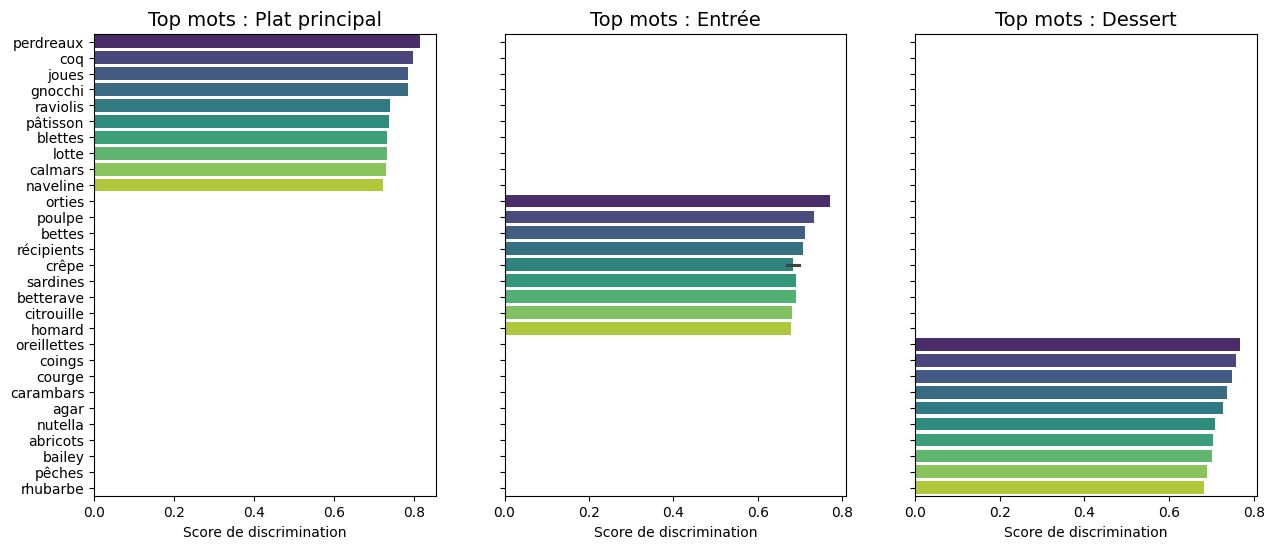

In [249]:
discriminant_plot(words_discriminant).savefig("../outputs/top_discriminant_words.png", 
                                              dpi=300, bbox_inches="tight")